In [1]:
import sys
sys.path.append('../python-pipeline/')
from modules import *
from wavelets import *

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, integrate, stats, interpolate
import seaborn as sn

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

In [3]:
# Load data
dataFrameLeft = pd.read_csv(f'../data/Subject001_left_global_acc.csv')
dataFrameLeft.rename(columns={'# time': 'time', 'acc_x': 'rawacc_x', 'acc_y': 'rawacc_y', 'acc_z': 'rawacc_z'}, inplace=True)

# Interpolate data
interpFx = interpolate.interp1d(dataFrameLeft.time, dataFrameLeft.values, axis=0)
sampleFreq = 64
dataFrameLeft = pd.DataFrame(interpFx(dataFrameLeft.time.iloc[0] +
                                      np.arange(int((dataFrameLeft.time.iloc[-1] - dataFrameLeft.time.iloc[0]) * sampleFreq),
                                                dtype=float) / sampleFreq),
                             columns=dataFrameLeft.columns)

b, a = signal.butter(4, 0.1 / (sampleFreq / 2), btype='highpass')
for d in 'xyz': dataFrameLeft[f'rawacc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])
dataFrameLeft

,time,rawacc_x,rawacc_y,rawacc_z,gyr_x,gyr_y,gyr_z
0,0.000000,1.784680,-2.063882,-0.994556,86.888381,-225.462894,-93.171504
1,0.015625,13.309397,-1.815104,-25.635554,122.545692,-40.309794,-59.608294
2,0.031250,19.454130,-7.326505,-33.033936,55.840785,-9.385509,-63.222420
3,0.046875,14.074922,-8.349677,-27.406278,11.221706,-66.800288,-71.703385
4,0.062500,3.639363,-3.786483,-21.072867,21.898373,-66.886228,-21.091462
...,...,...,...,...,...,...,...
66597,1040.578125,5.657215,10.196855,2.717974,29.745075,204.698459,-95.446399
66598,1040.593750,5.496628,9.507334,1.816568,70.152794,238.376332,-92.959887
66599,1040.609375,4.620012,7.727957,0.907288,112.388178,256.092014,-77.267492
66600,1040.625000,4.300819,6.965158,1.388687,100.050816,228.226640,-92.656228


In [4]:
# Select a time window to analyze
tIni, tFin = 100, 1000
tMask = (dataFrameLeft['time'] >= tIni) * (dataFrameLeft['time'] < tFin)
dataFrameLeft = dataFrameLeft[tMask]
dataFrameLeft.reset_index(inplace=True, drop=True)

In [5]:
# Set parameters for the IMU pipeline
usePower = False
waveletFunc = powerWavelet if usePower else accelerationWavelet
numFreq = 5
frequencies = torch.tensor([0.5, 1, 2, 4, 8])

numFilt = len(frequencies)
singleDim = False
dim = 1 if singleDim else 3

# Initialize IMU pipeline
nimup = NeuromorphicIMUPipeline(
    sampleFreq,
    globalFrame=True,
    usePower=usePower,
    singleDim=singleDim,
    frequencies=frequencies,
    waveletFunc=waveletFunc,
    maxFiltWin=(0.3,0)
)

In [6]:
# Forward pass data
# out = []
out1, out2 = [], []
for t, row in dataFrameLeft.iterrows():
    inp = row[[f'rawacc_{d}' for d in 'xyz']].to_numpy(dtype=float)
    # res = nimup(torch.Tensor(inp))
    # out += [res.numpy()]
    res1, res2 = nimup(torch.Tensor(inp))
    out1 += [res1.numpy()]
    out2 += [res2.numpy()]

In [7]:
# Store it in the dataframe
# outLabels = [f'spikes_{d}_{1/frequencies[j]:.2f}'
#              for d in ('xyz' if dim == 3 else '_') for j in range(numFilt)]
# dataFrameLeft[outLabels] = np.stack(out, 0).reshape(-1, dim * numFilt)
outLabels1 = [f'events_{d}_{1/frequencies[j]:.2f}'
             for d in ('xyz' if dim == 3 else '_') for j in range(numFilt)]
dataFrameLeft[outLabels1] = np.stack(out1, 0).reshape(-1, dim * numFilt)
outLabels2 = [f'spikes_{d}_{1/frequencies[j]:.2f}'
             for d in ('xyz' if dim == 3 else '_') for j in range(numFilt)]
dataFrameLeft[outLabels2] = np.stack(out2, 0).reshape(-1, dim * numFilt)

/usr/local/lib/python3.9/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


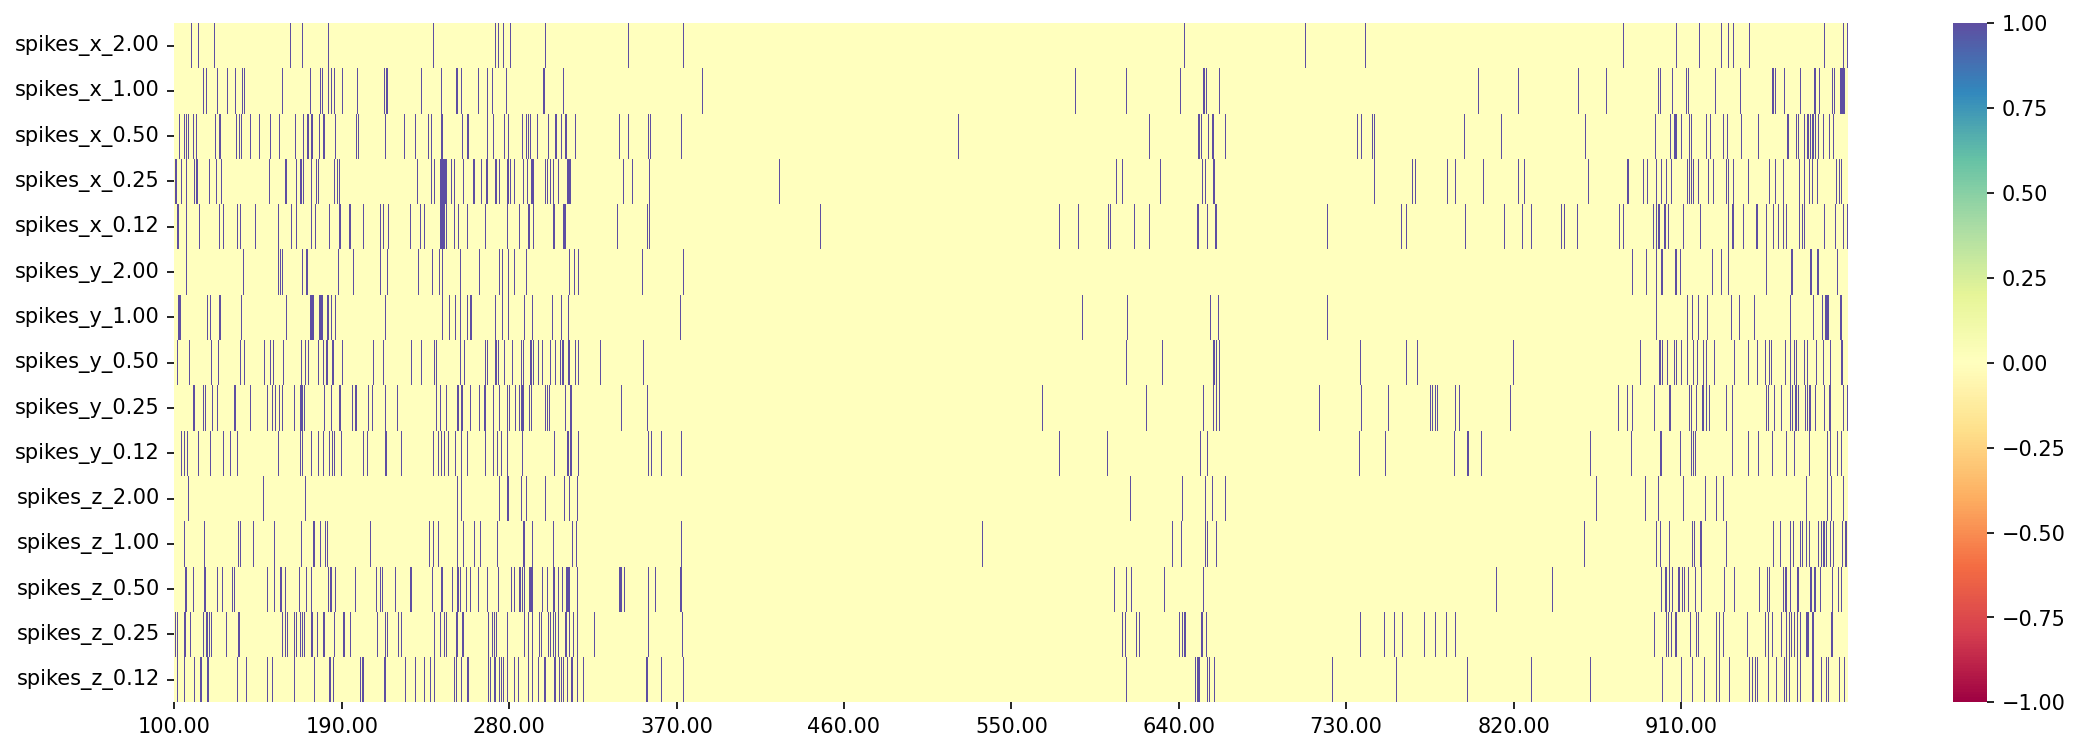

In [8]:
# Plot spikes
fig, ax = plt.subplots(1, 1, figsize=(18,6))
sn.heatmap(dataFrameLeft[outLabels2].T,
            xticklabels=len(dataFrameLeft)//10,
            yticklabels=True, cmap='Spectral', cbar=True, vmin=-1, vmax=1)
ax.set_xticklabels([f"{dataFrameLeft.loc[int(t.get_text()), 'time'].item():.2f}"
                    for t in ax.get_xticklabels()]);

In [9]:
# WARNING: This will throw error as dataFrameLeft['events_...'] is not defined.
#          To get dataFrameLeft['events_...'], we need to peek the signal of nimup
#          right after the max filter (modify previous cell and modules.py)

# Reconstruct signal
maxS = int((sampleFreq / frequencies).max())
maxM = int(np.min([2 * maxS, len(dataFrameLeft)]))
delayMaxFilter = nimup.get_submodule('_model.3.maxPooler').kernel_size[1]
delaySamples = maxS // 2 + delayMaxFilter // 2

for d in 'xyz':
    dataFrameLeft[f'rec_{d}'] = 0.0
    for j in range(numFilt):
        si = sampleFreq / frequencies[j]
        M = np.min([2 * si, len(dataFrameLeft)]).astype(int)
        impulse = signal.unit_impulse(maxM + delayMaxFilter, maxM // 2 - int(si) // 2)
        # nimup.get_submodule('model.2').filterBank.shape[0] // 2
        wavelet = signal.convolve(impulse, waveletFunc(si, si).flip(0), 'same')
        dataFrameLeft[f'rec_{d}'] += signal.convolve(dataFrameLeft[f'events_{d}_{1/frequencies[j]:.2f}'],
                                                     wavelet, 'same') / 3
        # plt.plot(wavelet)

/var/folders/h4/88x77ysj1yqdz6mr_x2f_w9c0000gn/T/ipykernel_25081/3015973643.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft[f'rec_{d}'] = 0.0
/var/folders/h4/88x77ysj1yqdz6mr_x2f_w9c0000gn/T/ipykernel_25081/3015973643.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrameLeft[f'rec_{d}'] += signal.convolve(dataFrameLeft[f'events_{d}_{1/frequencies[j]:.2f}'],


(100.0, 110.0)

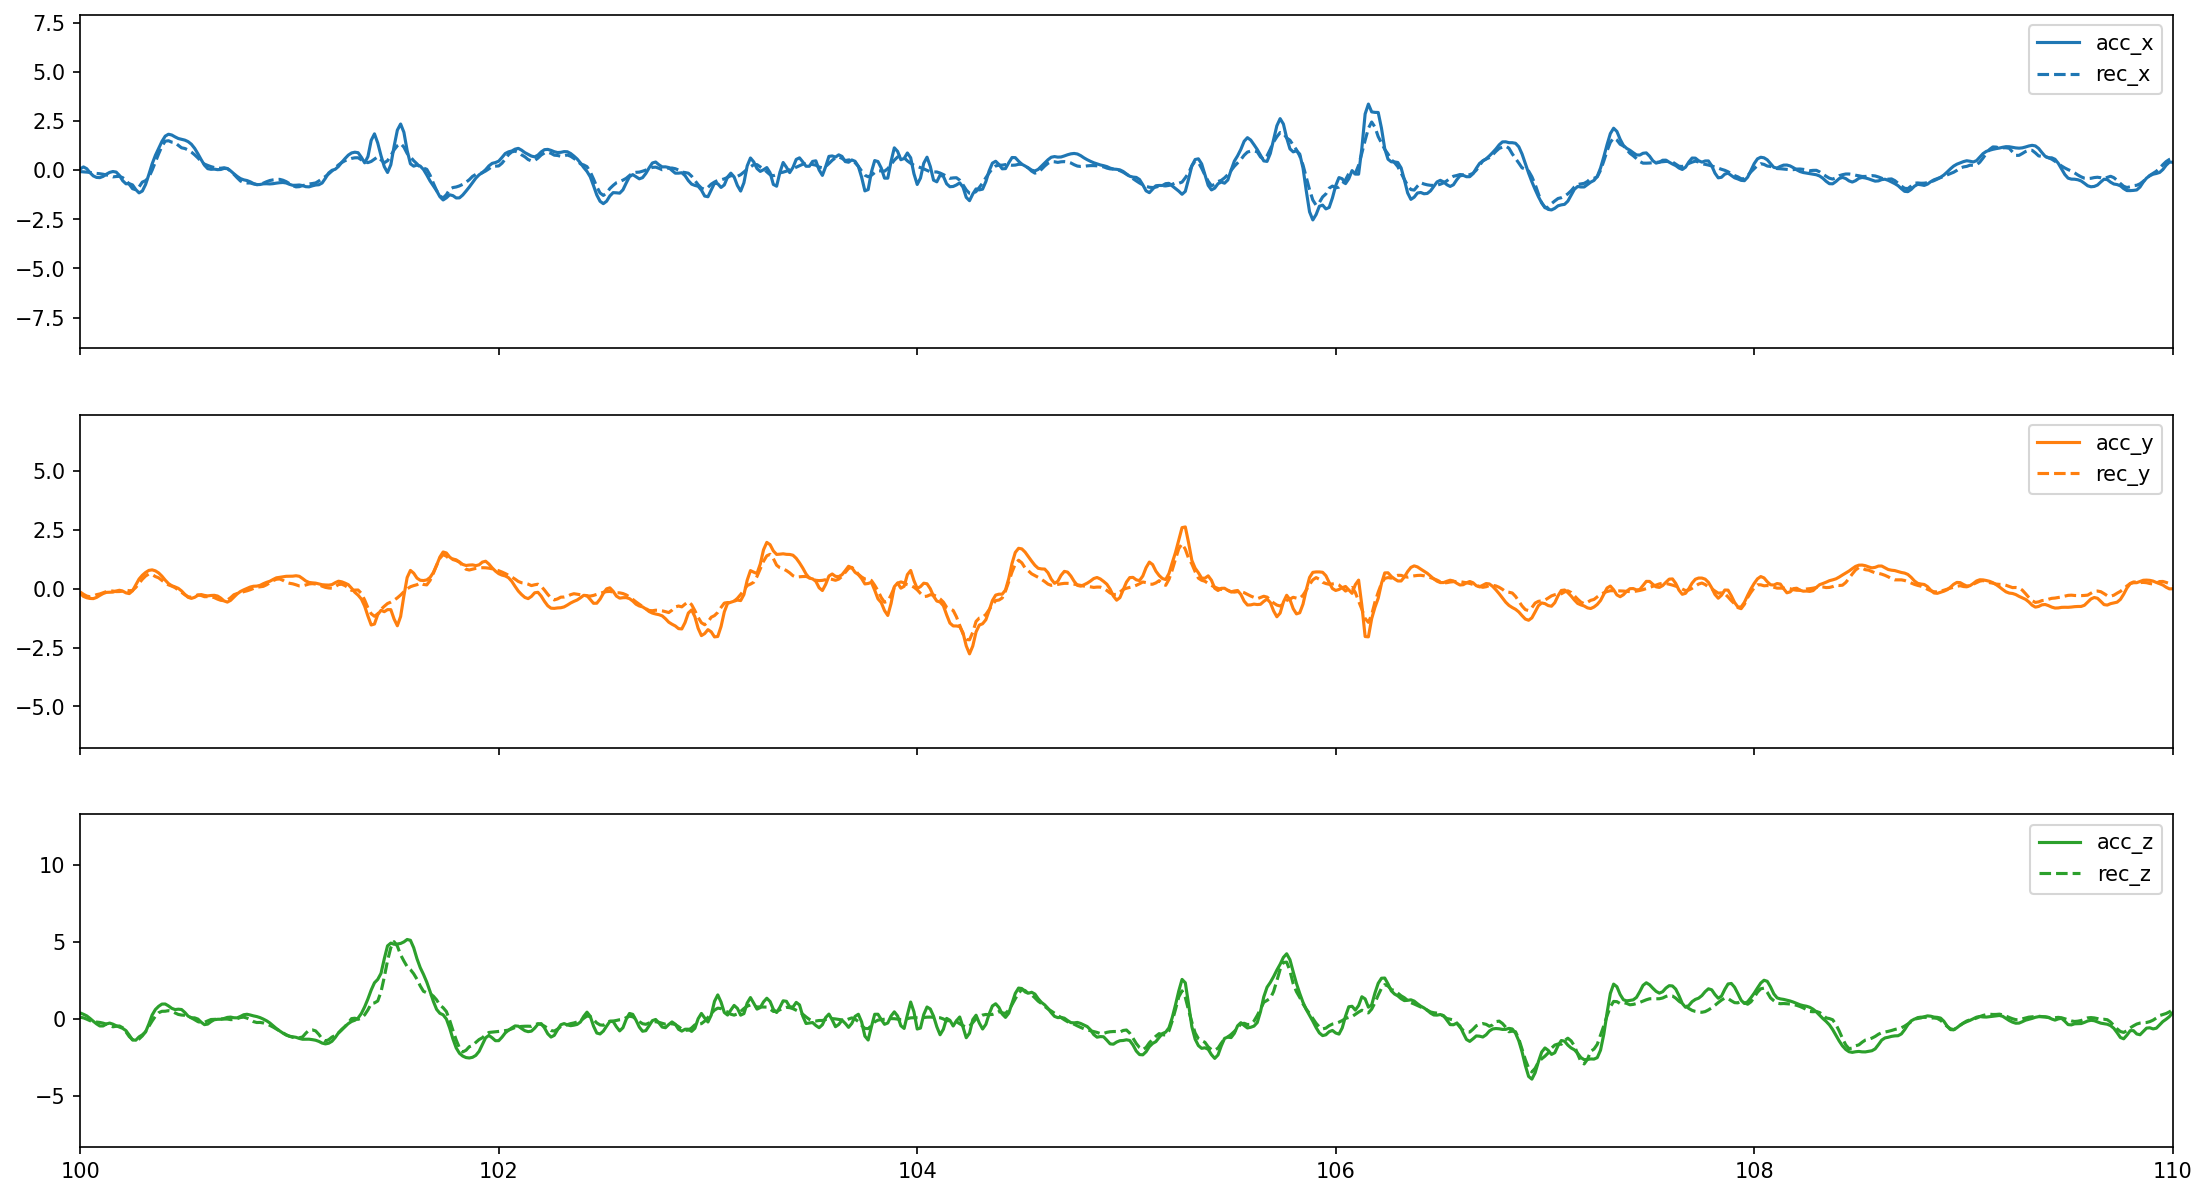

In [10]:
# Plot spikes
fig, ax = plt.subplots(3, 1, figsize=(18,10), sharex=True)

for i, (axi, d) in enumerate(zip(ax, 'xyz')):
    axi.plot(dataFrameLeft['time'][:], dataFrameLeft[f'rawacc_{d}'][:], '-', label=f'acc_{d}', color=f'C{i}')
    axi.plot(dataFrameLeft['time'][:], dataFrameLeft[f'rec_{d}'][:], '--', label=f'rec_{d}', color=f'C{i}')
    axi.legend()

axi.set_xlim(100,110)

In [11]:
# Get metrics (fix previous cell before running this)

# Signal to compare with
b, a = signal.butter(4, 20.0 / (sampleFreq / 2), btype='lowpass')
for d in 'xyz': dataFrameLeft[f'acc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])

inputs = dataFrameLeft[[f'acc_{d}' for d in 'xyz']].to_numpy()[:-delaySamples]
diffs = (dataFrameLeft[[f'acc_{d}' for d in 'xyz']].to_numpy()[:-delaySamples] -
         dataFrameLeft[[f'rec_{d}' for d in 'xyz']].to_numpy()[:-delaySamples])
spikes = dataFrameLeft[[f'spikes_{d}_{1/frequencies[j]:.2f}' for d in ('xyz' if dim == 3 else '_')
                        for j in range(numFilt)]].to_numpy()[:-delaySamples]

NRMSE = np.sqrt(((diffs) ** 2).mean()) / 9
SNR = np.sqrt((inputs ** 2).mean()) / np.sqrt((diffs ** 2).mean())
SD = spikes.mean() # spike density
SNRSD = SNR / SD

print('NRMSE [%]:', NRMSE * 100)
print('SNR [dB]:', 10 * np.log10(SNR))
print('Spk Density [%]:', 100 * SD)
print('SNR per Spk Density [dB]', 10 * np.log10(SNRSD))

NRMSE [%]: 2.937837989010895
SNR [dB]: 4.059955705316845
Spk Density [%]: 4.764603450894356
SNR per Spk Density [dB] 17.279688095772602


/var/folders/h4/88x77ysj1yqdz6mr_x2f_w9c0000gn/T/ipykernel_25081/385194231.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for d in 'xyz': dataFrameLeft[f'acc_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rawacc_{d}'])
